# libraries

In [3]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(tidyr)

# Load RDS

In [4]:

merged_sct <- readRDS("/Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/data/processed/merged_annotated_final.rds")


# Define cell types to exclude

In [5]:

exclude_types <- c(
  "Platelet (possible contamination)",
  "Erythrocyte (contamination)",
  "Low-quality/stressed cells (non-specific markers; consider excluding)",
  "Unresolved (low-information markers)",
  "HSPC (CD34+)"
)

clean_obj <- subset(merged_sct, cell_type %in% exclude_types, invert = TRUE)

cat("--before exclude :", ncol(merged_sct), "cells\n")
cat("--after exclude:", ncol(clean_obj), "cells\n")


--before exclude : 65865 cells
--after exclude: 62512 cells


# Module Score (ExhaustionScore)

In [6]:

exhaustion_genes <- list(c("PDCD1", "CTLA4", "LAG3", "HAVCR2", "TOX", "TIGIT"))
clean_obj <- AddModuleScore(clean_obj, features = exhaustion_genes,
                             name = "ExhaustionScore", assay = "SCT")
                             
# results in a new column in the metadata called "ExhaustionScore1"


# Calculate mean exhaustion score per patient and timepoint

## t-cell types to include in the analysis

In [7]:
# per patient and timepoint, calculate the mean exhaustion score and number of cells
t_cell_types <- c("Naive T-cell", "Naive CD4 T-cell", "CD4+ T helper",
                   "CD8+ T-cell", "CD8+ T-cell (effector/memory)",
                   "CD8+ T-cell (cytotoxic terminal)",
                   "CD8+ T-cell (effector/exhausted, EOMES+)",
                   "gd T-cell / MAIT", "Proliferating lymphocyte (MKI67+)")

t_cells_clean <- subset(clean_obj, cell_type %in% t_cell_types)


## patient_summary

In [8]:
# patient_summary 
patient_summary <- t_cells_clean@meta.data %>%
  group_by(patient_id, timepoint) %>%
  summarise(mean_exhaustion = mean(ExhaustionScore1), n_cells = n(), .groups = "drop")

write.csv(patient_summary, "/Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/results/tables/exhaustion_score_by_patient_timepoint.csv",
          row.names = FALSE)


## data visualization

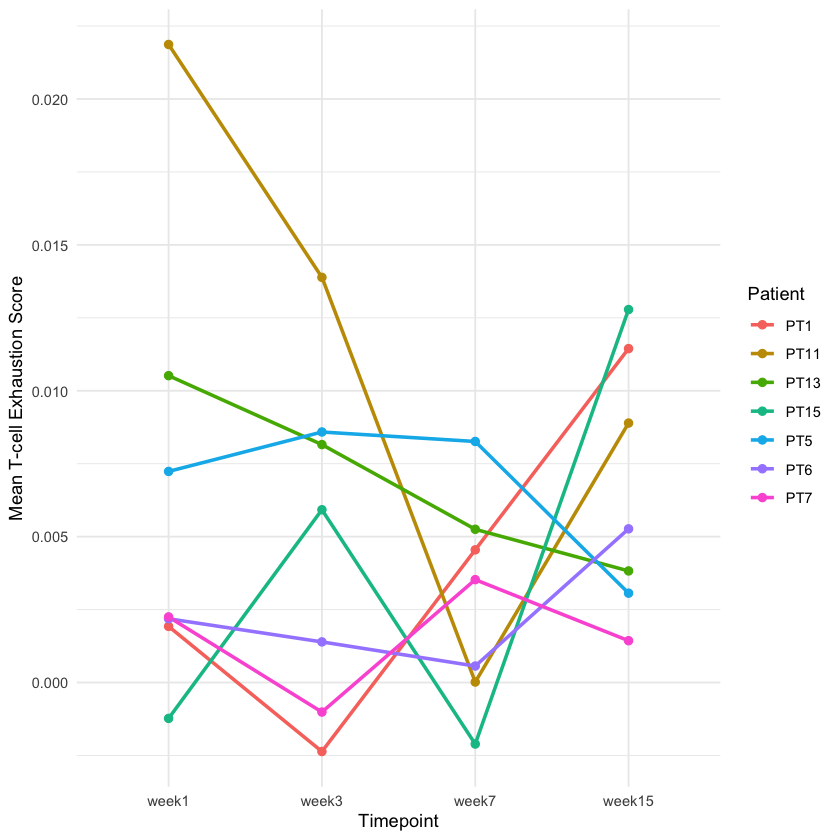

In [9]:
ggplot(patient_summary, aes(x = factor(timepoint, levels = c("week1","week3","week7","week15")),
                             y = mean_exhaustion, group = patient_id, color = patient_id)) +
  geom_line(linewidth = 1) + geom_point(size = 2) +
  labs(x = "Timepoint", y = "Mean T-cell Exhaustion Score", color = "Patient") +
  theme_minimal()
ggsave("/Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/results/figures/exhaustion_score_trajectory_per_patient.png",
       width = 8, height = 6, dpi = 300
)
# each line represents a patient, showing the trajectory of mean exhaustion score across timepoints



# Friedman test 

In [11]:
# non parametric Friedman test for repeated measures (suitable for n=7 patients across 4 timepoints)

wide_summary <- patient_summary %>%
  select(patient_id, timepoint, mean_exhaustion) %>%
  pivot_wider(names_from = timepoint, values_from = mean_exhaustion)

# include only patients with complete data across all timepoints 
complete_patients <- wide_summary %>% drop_na()
cat("Number of patients with complete data across all timepoints:", nrow(complete_patients), "\n")

if (nrow(complete_patients) >= 3) {
  mat <- as.matrix(complete_patients[, c("week1", "week3", "week7", "week15")])
  friedman_result <- friedman.test(mat)
  print(friedman_result)
} else {
  cat("Number of complete patients is not sufficient for the Friedman test; report descriptive results.\n")
}

saveRDS(clean_obj, "/Users/mehranbeyki/portfolio-projects/scrna-immune-checkpoint-response/data/processed/merged_clean_final.rds")

Number of patients with complete data across all timepoints: 7 

	Friedman rank sum test

data:  mat
Friedman chi-squared = 1.1143, df = 3, p-value = 0.7736

